# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VipS-2004/flyrank1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
!git clone https://github.com/VipS-2004/flyrank1.git

fatal: destination path 'flyrank1' already exists and is not an empty directory.


## 1. Question

*The research question and the decision it supports.*

## Research Question

Can content-level signals such as content age, traffic, CTR, position, engagement, and trend information provide useful directional evidence for prioritizing content for human review?

The decision supported by this analysis is which content items should be reviewed first. The goal is decision support and prioritization, not automatic content changes or proof that a specific intervention will improve performance.

In [ ]:
print("Research question:")
print(
    "Can content-level signals provide useful directional evidence "
    "for prioritizing content for human review?"
)

print("\nDecision supported:")
print(
    "Prioritize content items for human review using measured signals "
    "and a ranked action queue."
)

Research question:
Can content-level signals provide useful directional evidence for prioritizing content for human review?

Decision supported:
Prioritize content items for human review using measured signals and a ranked action queue.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This analysis uses the anonymized FlyRank content-refresh dataset provided for the ML internship. The working analysis extract contains 30,000 content records and 44 columns.

The dataset contains content-level performance and metadata signals, including content age, days since last update, impressions, clicks, sessions, CTR, average position, engagement rate, scroll rate, AI traffic percentage, word count, and trend information.

The analysis focuses on aggregate content-level signals that can support prioritization. Identifying information, private queries, client names, and other non-public information are not included in the research output.

The analysis does not expose individual client identities or private search information. The final paper is intended to describe the methodology and measured results at an aggregate, public-safe level.

The working extract used for this notebook represents the data available to this analysis; no additional date window or release detail is claimed here beyond what is documented in the supplied dataset and project materials.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/flyrank1/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nSelected analysis signals:")
display(
    pd.DataFrame({
        "feature": [
            "content_age_days",
            "days_since_last_update",
            "impressions_90d",
            "clicks_90d",
            "sessions_90d",
            "ai_traffic_pct",
            "word_count",
            "ctr",
            "avg_position",
            "engagement_rate",
            "scroll_rate",
            "trend_pct"
        ]
    })
)

Dataset shape: (30000, 44)
Number of rows: 30000
Number of columns: 44

Selected analysis signals:


,feature
0,content_age_days
1,days_since_last_update
2,impressions_90d
3,clicks_90d
4,sessions_90d
5,ai_traffic_pct
6,word_count
7,ctr
8,avg_position
9,engagement_rate


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

### Features

The analysis used selected content-level signals:

- content age
- days since last update
- impressions over 90 days
- clicks over 90 days
- sessions over 90 days
- AI traffic percentage
- word count
- CTR
- average position
- scroll rate
- trend percentage

### Label

The primary outcome examined was engagement rate. The analysis treated engagement rate as the measured outcome rather than assuming that the selected signals caused engagement.

### Baseline

The Week-4 baseline was a simple heuristic score based on content age, CTR, and engagement rate. The score was used as a prioritization baseline rather than as a predictive model.

### Model and validation

Week 5 compared model performance using a random split and then tested the model under a client-grouped split in Week 6. The client-grouped split was used as a more conservative test of whether the observed relationship would generalize across clients.

The measured results were:

- Random split: MAE = 3.064889, R² = 0.117171
- Client-grouped split: MAE = 3.333219, R² = -0.050984

The difference between the two splits suggests that the random-split result may overstate generalization to unseen clients.

### Leakage checks

The final feature set did not include the target variable or Week-4 derived fields such as `baseline_score`, `reason_code`, or `action`.

The final model features were checked explicitly before evaluation.

The analysis therefore treats the results as measured, directional evidence rather than proof of reliable generalization.

In [ ]:
# Final feature and leakage check

target = "engagement_rate"

final_features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ai_traffic_pct",
    "word_count",
    "ctr",
    "avg_position",
    "scroll_rate",
    "trend_pct"
]

week4_derived = [
    "baseline_score",
    "reason_code",
    "action"
]

print("Target in feature set:", target in final_features)

print("\nWeek-4 derived fields in feature set:")
for col in week4_derived:
    print(f"{col}: {col in final_features}")

print("\nFinal model features:")
print(final_features)

Target in feature set: False

Week-4 derived fields in feature set:
baseline_score: False
reason_code: False
action: False

Final model features:
['content_age_days', 'days_since_last_update', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'ai_traffic_pct', 'word_count', 'ctr', 'avg_position', 'scroll_rate', 'trend_pct']


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Week-5 model was evaluated against the same task under two validation designs.

| Validation split | MAE | R² |
|---|---:|---:|
| Random split (before) | 3.064889 | 0.117171 |
| Client-grouped split (after) | 3.333219 | -0.050984 |

The random split produced lower MAE and a positive R², while the client-grouped split produced higher MAE and a negative R². This indicates that performance was weaker when evaluated across client groups.

The Week-4 heuristic baseline had a mean baseline score of 0.772544. Because this is a different metric from the model's MAE and R², it is not treated as a directly comparable performance number. The baseline is instead reported as the earlier prioritization reference.

Overall, the measured results support using the analysis as directional decision-support evidence rather than claiming reliable generalization to unseen clients.

,Split,MAE,R2
0,Random split (before),3.064889,0.117171
1,Client-grouped split (after),3.333219,-0.050984


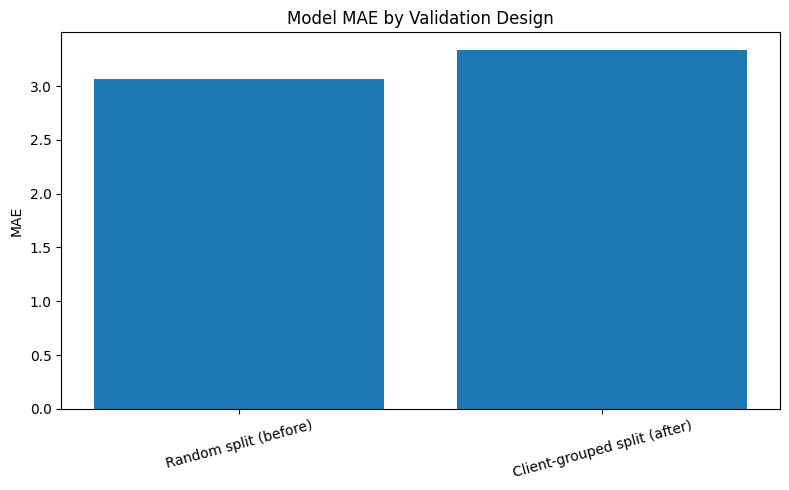

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual validation results from Weeks 5–6
comparison = pd.DataFrame({
    "Split": [
        "Random split (before)",
        "Client-grouped split (after)"
    ],
    "MAE": [
        3.064889,
        3.333219
    ],
    "R2": [
        0.117171,
        -0.050984
    ]
})

display(comparison)

# Plot MAE across validation designs
plt.figure(figsize=(8, 5))
plt.bar(comparison["Split"], comparison["MAE"])
plt.ylabel("MAE")
plt.title("Model MAE by Validation Design")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## Limitations

This analysis has several important limitations.

First, the working analysis uses a 30,000-row anonymized extract, so the results should not be generalized beyond the data and setting examined here.

Second, the measured relationship between the selected signals and engagement rate is directional. The analysis does not establish that changing a particular content signal will cause engagement to increase.

Third, the random split performed better than the client-grouped split. The client-grouped evaluation produced MAE = 3.333219 and R² = -0.050984, which indicates that the observed model performance did not reliably generalize across unseen client groups.

Fourth, the Week-4 heuristic baseline is a prioritization score rather than a directly comparable predictive metric to MAE or R². It should therefore be interpreted as an earlier decision-support reference rather than a competing model score.

Finally, the ranked recommendations are intended for human review. The analysis does not provide evidence that content changes will definitely improve performance, and no automated or irreversible action should be based on the ranking alone.

In [ ]:
# Summary of measured limitations

limitations = [
    "30,000-row anonymized analysis extract",
    "Directional relationships, not causal effects",
    "Weaker performance under client-grouped validation",
    "Baseline score is not directly comparable to MAE/R²",
    "Recommendations require human review"
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

1. 30,000-row anonymized analysis extract
2. Directional relationships, not causal effects
3. Weaker performance under client-grouped validation
4. Baseline score is not directly comparable to MAE/R²
5. Recommendations require human review


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The action playbook converts the measured signals into a practical review queue. These recommendations are prioritization guidance rather than automatic decisions.

### 1. Review stale content first

Content older than 365 days receives the `STALE_CONTENT` reason code and should be reviewed for freshness, accuracy, and continued relevance.

### 2. Review low-CTR content

The `LOW_CTR` reason code identifies content with low observed CTR. Reviewers should check titles, search intent, positioning, and how the page appears in search results before deciding whether a change is appropriate.

### 3. Review low-engagement content

The `LOW_ENGAGEMENT` reason code identifies content with weaker observed engagement signals. Reviewers should inspect relevance, clarity, content structure, and user experience.

### Human review rule

No recommendation should directly trigger publication, deletion, or an irreversible SEO/content change. The ranked queue only determines what should be reviewed first.

### Practical use

The queue can help a content team focus limited review time on higher-priority items while retaining human judgment over the final action.

In [ ]:
import pandas as pd

# Recreate the Week-7 ranked action queue
df = pd.read_csv(
    "/content/flyrank1/data/raw/content_refresh_anonymized.csv"
)

# Recreate the Week-4 baseline score
df["baseline_score"] = (
    0.4 * (df["content_age_days"] / df["content_age_days"].max())
    + 0.3 * (1 - df["ctr"] / 100)
    + 0.3 * (1 - df["engagement_rate"] / 100)
)

# Recreate reason codes
def reason(row):
    if row["content_age_days"] > 365:
        return "STALE_CONTENT"
    elif row["ctr"] < 2:
        return "LOW_CTR"
    else:
        return "LOW_ENGAGEMENT"

df["reason_code"] = df.apply(reason, axis=1)
df["action"] = "Refresh Content"

# Create ranked queue
queue = df.sort_values(
    "baseline_score",
    ascending=False
)

# Summary by reason code
recommendation_summary = (
    queue.groupby("reason_code")
    .agg(
        items=("content_id", "count"),
        average_score=("baseline_score", "mean")
    )
    .sort_values("average_score", ascending=False)
    .reset_index()
)

print("Recommendation summary:")
display(recommendation_summary)

print("\nTop 20 recommended items:")
display(
    queue[
        ["content_id", "baseline_score", "reason_code", "action"]
    ].head(20)
)

Recommendation summary:


,reason_code,items,average_score
0,STALE_CONTENT,6360,0.918499
1,LOW_CTR,22931,0.734021
2,LOW_ENGAGEMENT,709,0.709202



Top 20 recommended items:


,content_id,baseline_score,reason_code,action
3604,content_5f7d77cf01e3,0.995035,STALE_CONTENT,Refresh Content
2115,content_a0c3be8b0794,0.995035,STALE_CONTENT,Refresh Content
7500,content_5b5e85993c2b,0.995035,STALE_CONTENT,Refresh Content
19810,content_9d17befb32b0,0.995035,STALE_CONTENT,Refresh Content
7397,content_bb5a87d3be4f,0.995035,STALE_CONTENT,Refresh Content
25831,content_5466a8258699,0.995035,STALE_CONTENT,Refresh Content
25956,content_7faeb2d774be,0.995035,STALE_CONTENT,Refresh Content
12934,content_70641aa29f3e,0.995035,STALE_CONTENT,Refresh Content
12972,content_d5b833d82e72,0.995035,STALE_CONTENT,Refresh Content
17338,content_8e4c8d698268,0.995035,STALE_CONTENT,Refresh Content


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the Paper Embeds

The paper will reuse the measured validation comparison and the ranked recommendation output generated in this notebook.

The main result figure compares model MAE under the random split and the more conservative client-grouped split.

The recommendation table provides the ranked content queue with its baseline score, reason code, and suggested action.

These artifacts are generated from the analysis rather than manually edited so that the paper remains traceable to the notebook.

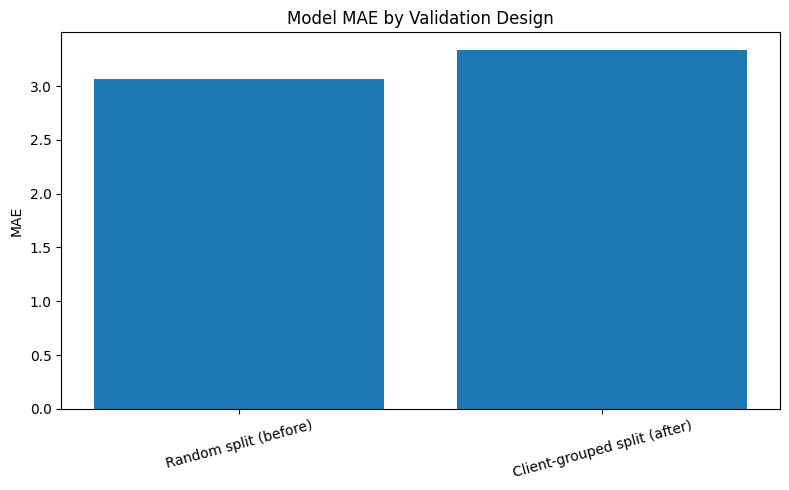

Figure saved to:
/content/flyrank1/work/figures/validation_mae_comparison.png

Recommendation artifact:


,content_id,baseline_score,reason_code,action
3604,content_5f7d77cf01e3,0.995035,STALE_CONTENT,Refresh Content
2115,content_a0c3be8b0794,0.995035,STALE_CONTENT,Refresh Content
7500,content_5b5e85993c2b,0.995035,STALE_CONTENT,Refresh Content
19810,content_9d17befb32b0,0.995035,STALE_CONTENT,Refresh Content
7397,content_bb5a87d3be4f,0.995035,STALE_CONTENT,Refresh Content
25831,content_5466a8258699,0.995035,STALE_CONTENT,Refresh Content
25956,content_7faeb2d774be,0.995035,STALE_CONTENT,Refresh Content
12934,content_70641aa29f3e,0.995035,STALE_CONTENT,Refresh Content
12972,content_d5b833d82e72,0.995035,STALE_CONTENT,Refresh Content
17338,content_8e4c8d698268,0.995035,STALE_CONTENT,Refresh Content


In [ ]:
import os
import matplotlib.pyplot as plt

# Create the figures directory
figures_dir = "/content/flyrank1/work/figures"
os.makedirs(figures_dir, exist_ok=True)

# Validation results
comparison = pd.DataFrame({
    "Split": [
        "Random split (before)",
        "Client-grouped split (after)"
    ],
    "MAE": [
        3.064889,
        3.333219
    ],
    "R2": [
        0.117171,
        -0.050984
    ]
})

# Save the validation figure
plt.figure(figsize=(8, 5))
plt.bar(comparison["Split"], comparison["MAE"])
plt.ylabel("MAE")
plt.title("Model MAE by Validation Design")
plt.xticks(rotation=15)
plt.tight_layout()

figure_path = os.path.join(
    figures_dir,
    "validation_mae_comparison.png"
)

plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path)

# Display the recommendation table used by the paper
print("\nRecommendation artifact:")
display(
    queue[
        ["content_id", "baseline_score", "reason_code", "action"]
    ].head(20)
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# 5-Minute Demo Outline

## 1. Question — 45 seconds

FlyRank's content teams need a practical way to identify which content may deserve attention or a refresh.

My question was: can measurable content signals help prioritize which pages a human reviewer should inspect first?

## 2. Method — 1 minute

I used content-level signals including content age, days since last update, impressions, clicks, sessions, CTR, average position, AI traffic percentage, word count, scroll rate, and trend percentage.

I compared model performance using a random split and a more conservative client-grouped split. I also checked the final feature set for leakage.

## 3. One Chart — 45 seconds

I would show the "Model MAE by Validation Design" chart.

It compares the model's MAE under the random split with the client-grouped split.

## 4. One Honest Result — 1 minute

The random split produced an MAE of 3.064889 and R² of 0.117171.

The client-grouped split produced an MAE of 3.333219 and R² of -0.050984.

The grouped result was weaker, so I would not claim that the model reliably generalizes to new clients. The result is better treated as directional, decision-support evidence.

## 5. One Recommendation — 1 minute

Use the ranked output to help a human reviewer decide what content to inspect first.

The queue uses reason codes such as STALE_CONTENT, LOW_CTR, and LOW_ENGAGEMENT.

The system should not automatically publish, delete pages, make SEO changes, or perform irreversible actions. A human should review the evidence before taking action.

# Shareable Cuts

## Short Social Post

I built and evaluated a content-performance analysis using the FlyRank ML Internship dataset. I compared a standard random split with a client-grouped validation split and also performed a feature leakage audit. The grouped validation result was weaker, which showed me why validation design matters and why the current findings should be treated as directional decision-support evidence rather than proof of reliable generalization. The final output is a ranked content-review queue with reason codes and human-review recommendations.

## Employer-Facing Summary

I built a content-performance analysis using the FlyRank ML Internship dataset, using signals such as content freshness, traffic, CTR, engagement, and trends. I evaluated the model using both random and client-grouped validation and performed a leakage audit before creating a ranked action queue. The results showed weaker performance under client-grouped validation, so I framed the system as human-reviewed decision support rather than claiming reliable generalization.